**Exploratory Data Analysis (EDA)**

**Claudia Galdamez**

**Milestone 2**


**Overview:**

In this analysis, I explore Medicare Part D prescription drug spending data to better understand how drug usage relates to cost. The goal is to prepare the data for a model that classifies drugs as high-cost or low-cost.

In [ ]:
#Load Data into google collab
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/content/DSD_PTD_RY25_P04_V10_DY23_BGM.csv")

#View rows in Data
df.head()

,Brnd_Name,Gnrc_Name,Tot_Mftr,Mftr_Name,Tot_Spndng_2019,Tot_Dsg_Unts_2019,Tot_Clms_2019,Tot_Benes_2019,Avg_Spnd_Per_Dsg_Unt_Wghtd_2019,Avg_Spnd_Per_Clm_2019,...,Tot_Spndng_2023,Tot_Dsg_Unts_2023,Tot_Clms_2023,Tot_Benes_2023,Avg_Spnd_Per_Dsg_Unt_Wghtd_2023,Avg_Spnd_Per_Clm_2023,Avg_Spnd_Per_Bene_2023,Outlier_Flag_2023,Chg_Avg_Spnd_Per_Dsg_Unt_22_23,CAGR_Avg_Spnd_Per_Dsg_Unt_19_23
0,1st Tier Unifine Pentips,"Pen Needle, Diabetic",1,Overall,139201.68,642471.0,5392.0,1878.0,0.216788,25.816335,...,44355.04,195672.0,1613,699.0,0.227162,27.498475,63.454993,0.0,0.005702,0.011754
1,1st Tier Unifine Pentips,"Pen Needle, Diabetic",1,Owen Mumford Us,139201.68,642471.0,5392.0,1878.0,0.216788,25.816335,...,44355.04,195672.0,1613,699.0,0.227162,27.498475,63.454993,0.0,0.005702,0.011754
2,1st Tier Unifine Pentips Plus,"Pen Needle, Diabetic",1,Overall,343031.42,1830596.0,14581.0,5319.0,0.187389,23.525919,...,97951.18,406617.0,3269,1267.0,0.240932,29.963652,77.309534,0.0,0.022165,0.064848
3,1st Tier Unifine Pentips Plus,"Pen Needle, Diabetic",1,Owen Mumford Us,343031.42,1830596.0,14581.0,5319.0,0.187389,23.525919,...,97951.18,406617.0,3269,1267.0,0.240932,29.963652,77.309534,0.0,0.022165,0.064848
4,Abacavir,Abacavir Sulfate,5,Overall,10110328.45,3316293.0,42629.0,6085.0,3.482725,237.170200,...,5287295.41,1648593.0,19632,2809.0,3.594357,269.320263,1882.269637,0.0,-0.071481,0.007919


In [ ]:
#View all columns in data
df.columns

Index(['Brnd_Name', 'Gnrc_Name', 'Tot_Mftr', 'Mftr_Name', 'Tot_Spndng_2019',
       'Tot_Dsg_Unts_2019', 'Tot_Clms_2019', 'Tot_Benes_2019',
       'Avg_Spnd_Per_Dsg_Unt_Wghtd_2019', 'Avg_Spnd_Per_Clm_2019',
       'Avg_Spnd_Per_Bene_2019', 'Outlier_Flag_2019', 'Tot_Spndng_2020',
       'Tot_Dsg_Unts_2020', 'Tot_Clms_2020', 'Tot_Benes_2020',
       'Avg_Spnd_Per_Dsg_Unt_Wghtd_2020', 'Avg_Spnd_Per_Clm_2020',
       'Avg_Spnd_Per_Bene_2020', 'Outlier_Flag_2020', 'Tot_Spndng_2021',
       'Tot_Dsg_Unts_2021', 'Tot_Clms_2021', 'Tot_Benes_2021',
       'Avg_Spnd_Per_Dsg_Unt_Wghtd_2021', 'Avg_Spnd_Per_Clm_2021',
       'Avg_Spnd_Per_Bene_2021', 'Outlier_Flag_2021', 'Tot_Spndng_2022',
       'Tot_Dsg_Unts_2022', 'Tot_Clms_2022', 'Tot_Benes_2022',
       'Avg_Spnd_Per_Dsg_Unt_Wghtd_2022', 'Avg_Spnd_Per_Clm_2022',
       'Avg_Spnd_Per_Bene_2022', 'Outlier_Flag_2022', 'Tot_Spndng_2023',
       'Tot_Dsg_Unts_2023', 'Tot_Clms_2023', 'Tot_Benes_2023',
       'Avg_Spnd_Per_Dsg_Unt_Wghtd_2023', 'Avg_S

In [ ]:
#Check shape of data (rows,columns)
df.shape

(14309, 46)

The dataset has 46 columns, with the same types of variables repeated for each year (2019–2023), like spending, claims, and beneficiaries. There are both text columns (names) and numeric columns (totals and averages).

It has 14,309 rows, so each row looks like one item with data tracked across multiple years.

**Data Description:**

The dataset comes from the Centers for Medicare & Medicaid Services and includes prescription drug spending information.

For this analysis, I focus on two main variables to understand how usage relates to cost.
- Total drug spending (Tot_Spndng_2023)
- Total claims (Tot_Clms_2023)


In [ ]:
#Data info and Type
df.info()
df[['Tot_Spndng_2023', 'Tot_Clms_2023']].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14309 entries, 0 to 14308
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Brnd_Name                        14309 non-null  object 
 1   Gnrc_Name                        14309 non-null  object 
 2   Tot_Mftr                         14309 non-null  int64  
 3   Mftr_Name                        14309 non-null  object 
 4   Tot_Spndng_2019                  10104 non-null  float64
 5   Tot_Dsg_Unts_2019                10104 non-null  float64
 6   Tot_Clms_2019                    10104 non-null  float64
 7   Tot_Benes_2019                   10017 non-null  float64
 8   Avg_Spnd_Per_Dsg_Unt_Wghtd_2019  10104 non-null  float64
 9   Avg_Spnd_Per_Clm_2019            10104 non-null  float64
 10  Avg_Spnd_Per_Bene_2019           9910 non-null   float64
 11  Outlier_Flag_2019                10102 non-null  float64
 12  Tot_Spndng_2020   

,Tot_Spndng_2023,Tot_Clms_2023
count,1.430900e+04,1.430900e+04
mean,3.856657e+07,2.261006e+05
std,3.442068e+08,1.453424e+06
min,3.118000e+01,1.100000e+01
25%,4.260451e+04,2.470000e+02
50%,7.494522e+05,2.847000e+03
75%,6.741554e+06,3.529400e+04
max,1.827345e+10,6.849370e+07


I used info() to get a quick look at the dataset, like the column types and if there are any missing values. Both total spending and total claims are numeric, and there are very few missing values in these columns.

Then I used describe() to see basic stats like the average, min, max, and median.

I noticed the max values are much higher than the median, especially for total spending. This suggests the data is skewed, with a few drugs having much higher costs than the rest. A similar pattern appears with claims, where some drugs are used much more frequently than others.

In [ ]:
#Check for missing values

df[['Tot_Spndng_2023', 'Tot_Clms_2023']].isnull().sum()

,0
Tot_Spndng_2023,0
Tot_Clms_2023,0


**Missing Values:**

There are very few missing values in the selected columns. Any missing values will be removed to keep the dataset clean.

In [ ]:
#Drop missing values

df_small = df[['Tot_Spndng_2023', 'Tot_Clms_2023']].dropna()

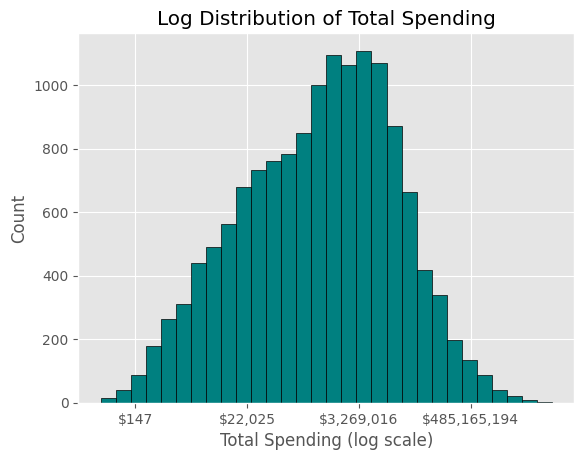

In [ ]:
import numpy as np
#Distributions
plt.style.use('ggplot')

plt.hist(np.log1p(df_small['Tot_Spndng_2023']), bins=30, color='teal', edgecolor='black')
plt.title("Log Distribution of Total Spending")
plt.xlabel("Total Spending (log scale)")
plt.ylabel("Count")

#labels
ticks = [5, 10, 15, 20]
labels = [f"${int(np.expm1(tick)):,}" for tick in ticks]
plt.xticks(ticks, labels)

plt.show()

This distribution helps show how drug spending is spread across the dataset. Most drugs have lower spending, while a smaller number have much higher costs. This supports the need to classify drugs into high-cost and low-cost categories for the model.

In [ ]:
import numpy as np
#Log transfomration:

df_small['log_spending'] = np.log1p(df_small['Tot_Spndng_2023'])
df_small['log_claims'] = np.log1p(df_small['Tot_Clms_2023'])

**Log Transformation**

The data is highly skewed, so a log transformation was applied to make it easier to visualize. This spreads out the values and makes patterns easier to see. The values are scaled, so they do not represent the original amounts directly.

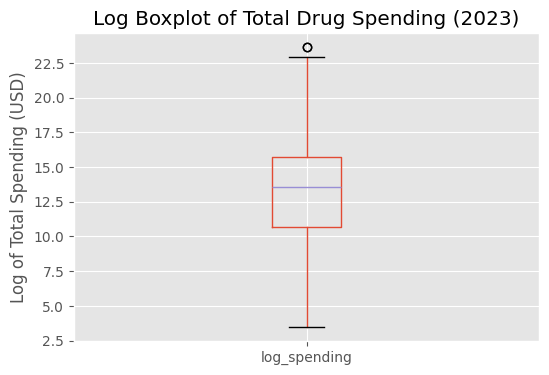

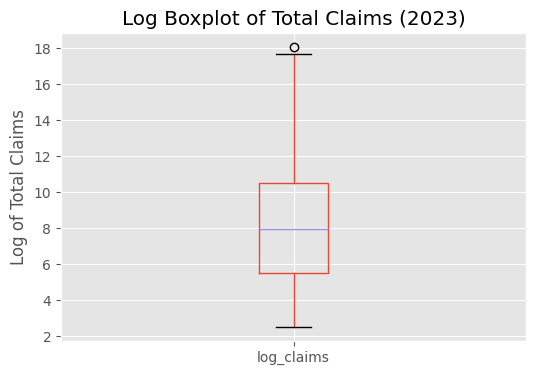

In [ ]:
#Outliers

plt.figure(figsize=(6,4))
df_small.boxplot(column=['log_spending'])
plt.title("Log Boxplot of Total Drug Spending (2023)")
plt.ylabel("Log of Total Spending (USD)")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
df_small.boxplot(column=['log_claims'])
plt.title("Log Boxplot of Total Claims (2023)")
plt.ylabel("Log of Total Claims")
plt.grid(True)
plt.show()

**Outliers:**

The original data was highly skewed, so a log transformation was used to improve visualization.

After applying the log scale, the boxplots are easier to read. There are still outliers present, which represent drugs with much higher spending or usage than others.

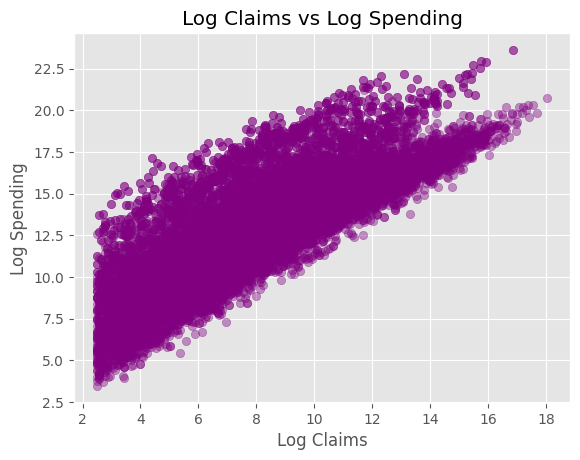

In [ ]:
#Relationship (scatter)
plt.scatter(df_small['log_claims'], df_small['log_spending'], alpha=0.4, color='purple')
plt.xlabel("Log Claims")
plt.ylabel("Log Spending")
plt.title("Log Claims vs Log Spending")
plt.show()

**Relationship Between claims and spending**

There is a positive relationship between claims and spending. As the number of claims increases, total spending also increases.

In [ ]:
#Correlation

df_small[['Tot_Clms_2023', 'Tot_Spndng_2023']].corr()

,Tot_Clms_2023,Tot_Spndng_2023
Tot_Clms_2023,1.000000,0.264014
Tot_Spndng_2023,0.264014,1.000000


The correlation between total claims and total spending is positive, but not very strong (around 0.26).

This means that while there is a relationship between usage and cost, it is not perfectly linear. Some drugs may have high spending without a very high number of claims, which could be due to higher prices per drug.

Overall, this still supports the idea that usage plays a role in cost, but other factors may also influence total spending.

In [ ]:
#Create Target value

threshold = df_small['Tot_Spndng_2023'].median()

df_small['high_cost'] = (df_small['Tot_Spndng_2023'] > threshold).astype(int)

df_small.head()

,Tot_Spndng_2023,Tot_Clms_2023,log_spending,log_claims,high_cost
0,44355.04,1613,10.700004,7.386471,0
1,44355.04,1613,10.700004,7.386471,0
2,97951.18,3269,11.492235,8.092545,0
3,97951.18,3269,11.492235,8.092545,0
4,5287295.41,19632,15.480818,9.884967,1


A new variable was created to classify drugs as high-cost or low-cost based on the median spending.

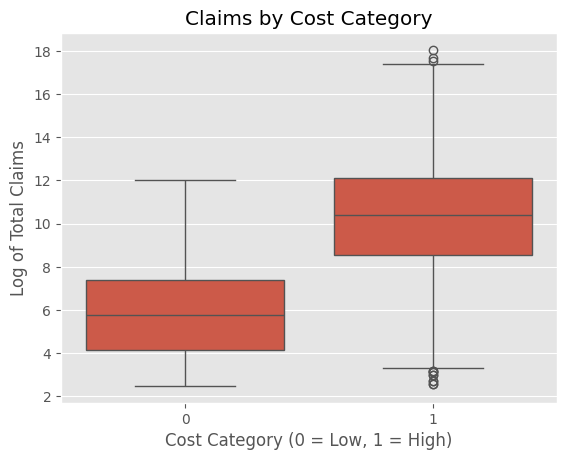

In [ ]:
#Feature vs Target
sns.boxplot(x='high_cost', y='log_claims', data=df_small)
plt.title("Claims by Cost Category")
plt.xlabel("Cost Category (0 = Low, 1 = High)")
plt.ylabel("Log of Total Claims")
plt.show()

**Feature vs Target**

High-cost drugs usually have more claims than low-cost drugs. The high-cost group is higher overall, which shows that usage is related to cost.

**Redundant Features:**

Since this analysis focuses only on total spending and total claims, there are no redundant features included.

**Hypothesis and Findings**

The initial assumption was that higher usage leads to higher cost. The analysis supports this, as there is a clear relationship between claims and spending.

Based on this, total claims is a useful feature for predicting whether a drug is high-cost or low-cost.

**Conclusion**

Overall, the analysis shows that drug usage is related to cost, but not perfectly. High-cost drugs tend to have higher usage, but other factors may also influence spending.

# Milestone 3: Feature Engineering
**Transition to Feature Engineering**

After exploring the data in Milestone 2, I noticed the data is skewed and some features could be improved.  
In this next step, I will create new features and transform the data to prepare it for modeling.


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/DSD_PTD_RY25_P04_V10_DY23_BGM.csv")

# Preview
df.head()

,Brnd_Name,Gnrc_Name,Tot_Mftr,Mftr_Name,Tot_Spndng_2019,Tot_Dsg_Unts_2019,Tot_Clms_2019,Tot_Benes_2019,Avg_Spnd_Per_Dsg_Unt_Wghtd_2019,Avg_Spnd_Per_Clm_2019,...,Tot_Spndng_2023,Tot_Dsg_Unts_2023,Tot_Clms_2023,Tot_Benes_2023,Avg_Spnd_Per_Dsg_Unt_Wghtd_2023,Avg_Spnd_Per_Clm_2023,Avg_Spnd_Per_Bene_2023,Outlier_Flag_2023,Chg_Avg_Spnd_Per_Dsg_Unt_22_23,CAGR_Avg_Spnd_Per_Dsg_Unt_19_23
0,1st Tier Unifine Pentips,"Pen Needle, Diabetic",1,Overall,139201.68,642471.0,5392.0,1878.0,0.216788,25.816335,...,44355.04,195672.0,1613,699.0,0.227162,27.498475,63.454993,0.0,0.005702,0.011754
1,1st Tier Unifine Pentips,"Pen Needle, Diabetic",1,Owen Mumford Us,139201.68,642471.0,5392.0,1878.0,0.216788,25.816335,...,44355.04,195672.0,1613,699.0,0.227162,27.498475,63.454993,0.0,0.005702,0.011754
2,1st Tier Unifine Pentips Plus,"Pen Needle, Diabetic",1,Overall,343031.42,1830596.0,14581.0,5319.0,0.187389,23.525919,...,97951.18,406617.0,3269,1267.0,0.240932,29.963652,77.309534,0.0,0.022165,0.064848
3,1st Tier Unifine Pentips Plus,"Pen Needle, Diabetic",1,Owen Mumford Us,343031.42,1830596.0,14581.0,5319.0,0.187389,23.525919,...,97951.18,406617.0,3269,1267.0,0.240932,29.963652,77.309534,0.0,0.022165,0.064848
4,Abacavir,Abacavir Sulfate,5,Overall,10110328.45,3316293.0,42629.0,6085.0,3.482725,237.170200,...,5287295.41,1648593.0,19632,2809.0,3.594357,269.320263,1882.269637,0.0,-0.071481,0.007919


Before creating new features, I first looked at the dataset again to understand what variables I can improve or combine. My main focus is on total spending and total claims since those are the most relevant to my goal.

In [ ]:
# Check missing values
df.isnull().sum()

# Drop missing values (simple approach for now)
df = df.dropna()

I checked for missing values and removed them. Since this dataset is large, dropping missing rows will not impact the results too much. This keeps the data clean and avoids errors during modeling.

In [ ]:
# Create threshold using median
threshold = df['Tot_Spndng_2023'].median()

# Create new target column
df['Cost_Category'] = df['Tot_Spndng_2023'].apply(lambda x: 1 if x > threshold else 0)

df[['Tot_Spndng_2023', 'Cost_Category']].head()

,Tot_Spndng_2023,Cost_Category
0,44355.04,0
1,44355.04,0
2,97951.18,0
3,97951.18,0
4,5287295.41,1


I created a new column called Cost_Category.  
If total spending is above the median, it is labeled as 1 (high cost). Otherwise, it is 0 (low cost).  

This converts my problem into a classification problem.

In [ ]:
# New feature
df['Spending_per_Claim'] = df['Tot_Spndng_2023'] / df['Tot_Clms_2023']

df[['Spending_per_Claim']].head()

,Spending_per_Claim
0,27.498475
1,27.498475
2,29.963652
3,29.963652
4,269.320263


**Data Source**

The dataset used in this analysis comes from the Centers for Medicare & Medicaid Services (CMS) and is part of the Medicare Part D Spending by Drug dataset.

Data can be accessed here:
https://data.cms.gov/summary-statistics-on-use-and-payments/medicare-medicaid-spending-by-drug/medicare-part-d-spending-by-drug